# Анализ закономерностей жителей деревни из Animal Crossing New Horizons и возможности их влияния на поведение игроков

**Краткое описание работы:** Был проведен анализ датасета Villagers из Каталога игры Animal Crossing New Horizons и обнаружены закономерности в формировании характеров, привычек и вкусов жителей деревни. Найденные корреляции оказывают непосредственное влияние на поведения игроков, побуждая их к определеным игровым паттернам. 
Была произведена очистка и анализ данных при помощи Python и библиотеки Pandas, а также визуализация с использование библиотеки Matplotlib. Cделаны выводы и потенциальные рекомендации для Геймдев команд в рамках влияния на игровые паттерны, возможности маркетинга и выбора системы монетизации.

**Задача**: Провести анализ характеристик жителей деревни из игры "Animal Crossing New Horizons" и выявить присутствующие связи в данных, силу этих связей и их направленность, и определить - присутствуют ли характерные паттерны при формировании жителей и на что они могли повлиять в игровом процессе.

Данные взяты из открытого источника - датасеты на Kaggle. Датасет взят из архива "Animal Crossing New Horizons Catalog" 
Ссылка: https://www.kaggle.com/datasets/jessicali9530/animal-crossing-new-horizons-nookplaza-dataset

**Основные идеи для анализа:**
1. Какие типы личностей наиболее распространены?
2. Есть ли связь между хобби и личностью?
3. Какие виды животных наиболее разнообразны по характеру?
4. Есть ли сезонные типы личности, способные повлиять на деятельность игрока?

== Идеи будут дополняться/изменяться в течении исследования. ==

In [1]:
import pandas as pd

df = pd.read_csv('villagers.csv')
print(df.head())
print(df.info())

      Name    Species  Gender Personality    Hobby Birthday Catchphrase  \
0  Admiral       Bird    Male      Cranky   Nature   27-Jan     aye aye   
1  Agent S   Squirrel  Female       Peppy  Fitness    2-Jul    sidekick   
2    Agnes        Pig  Female  Big Sister     Play   21-Apr     snuffle   
3       Al    Gorilla    Male        Lazy  Fitness   18-Oct     ayyyeee   
4  Alfonso  Alligator    Male        Lazy     Play    9-Jun    it'sa me   

   Favorite Song Style 1  Style 2 Color 1 Color 2               Wallpaper  \
0     Steep Hill    Cool     Cool   Black    Blue          dirt-clod wall   
1  Go K.K. Rider  Active   Simple    Blue   Black           concrete wall   
2     K.K. House  Simple  Elegant    Pink   White  gray molded-panel wall   
3  Go K.K. Rider  Active   Active     Red   White           concrete wall   
4    Forest Life  Simple   Simple     Red    Blue    yellow playroom wall   

                 Flooring                                     Furniture List  \
0     

In [8]:
# Настройка библиотек визуализациия
import piplite
await piplite.install('seaborn')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


1. Какие типы личностей наиболее распространены среди жителей?

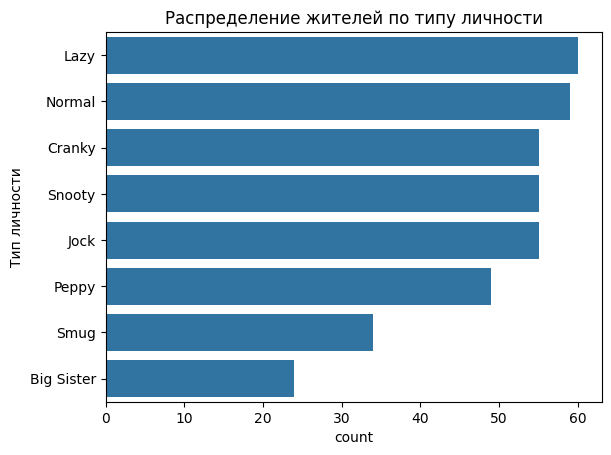

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y='Personality', data=df, order=df['Personality'].value_counts().index)
plt.title('Распределение жителей по типу личности')
plt.ylabel('Тип личности')
plt.show()

Согласно графику выше, наиболее распространенная черта личности среди жителей - "Ленивый". Ею обладают 60 жителей из 391. Далее, в порядке убывания, идут черты "Нормальный", "Капризный", "Высокомерный" и "Спортивный", закрывая топ-5

2. Есть ли связь между хобби и личностью?

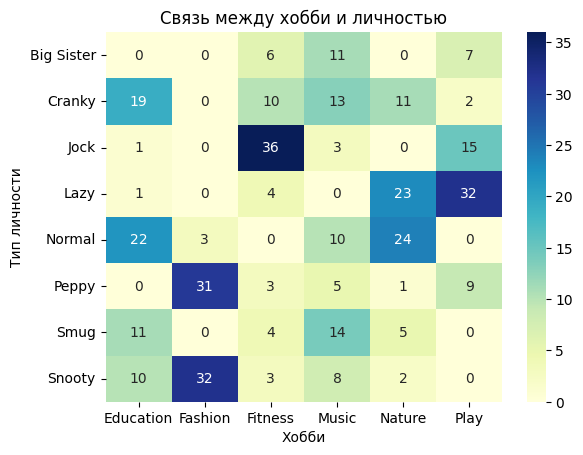

In [14]:
hobby_personality = pd.crosstab(df['Personality'], df['Hobby'])

sns.heatmap(hobby_personality, annot=True, cmap='YlGnBu')
plt.title('Связь между хобби и личностью')
plt.ylabel('Тип личности')
plt.xlabel('Хобби')
plt.show()

Согласно тепловой карте, среди данных присутствует корреляция между переменными типа личности жителя и его хобби.

3. Какие виды животных наиболее разнообразны по характеру?

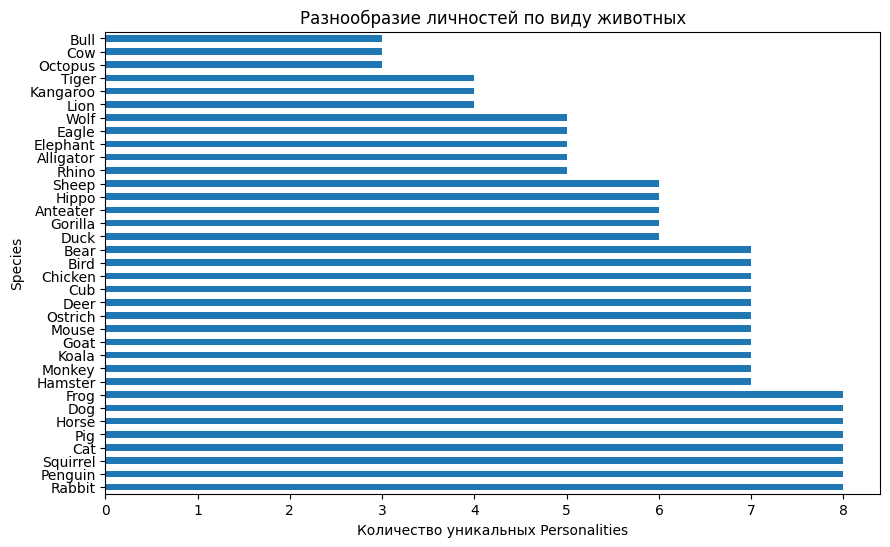

In [15]:
species_personality_count = df.groupby('Species')['Personality'].nunique().sort_values(ascending=False)

species_personality_count.plot(kind='barh', figsize=(10, 6))
plt.title('Разнообразие личностей по виду животных')
plt.xlabel('Количество уникальных Personalities')
plt.show()